In [10]:
import pandas as pd
import numpy as np

In [ ]:

# Cargar los DataFrames desde los archivos
df_abierto = pd.read_csv('res_contacts_filtrad03abierto.dat', delim_whitespace=True)
df_cerrado = pd.read_csv('res_contacts_filtrad03cerrado.dat', delim_whitespace=True)

# Filtrar el DataFrame para obtener los contactos en común entre los dos archivos
contactos_en_comun = pd.merge(df_abierto, df_cerrado, on=['#Res1', '#Res2'])

# Seleccionar las columnas originales y renombrarlas adecuadamente
contactos_en_comun = contactos_en_comun[['#Res1', '#Res2', 'TotalFrac_x', 'Contacts_x']]
contactos_en_comun = contactos_en_comun.drop_duplicates()
contactos_en_comun.columns = ['#Res1', '#Res2', 'TotalFrac', 'Contacts']

# Guardar el DataFrame en un archivo
contactos_en_comun.to_csv('contactos_en_comun03.dat', sep=' ', index=False)

FileNotFoundError: [Errno 2] No such file or directory: 'res_contacts_filtrad03abierto.dat'

In [1]:
import pandas as pd

def obtener_contactos_en_comun(file_abierto, file_cerrado, output_file):

    # Cargar los DataFrames desde los archivos
    df_abierto = pd.read_csv(file_abierto, delim_whitespace=True)
    df_cerrado = pd.read_csv(file_cerrado, delim_whitespace=True)

    # Filtrar el DataFrame para obtener los contactos en común entre los dos archivos
    contactos_en_comun = pd.merge(df_abierto, df_cerrado, on=['#Res1', '#Res2'])

    # Seleccionar las columnas originales y renombrarlas adecuadamente
    contactos_en_comun = contactos_en_comun[['#Res1', '#Res2', 'TotalFrac_x', 'Contacts_x']]
    contactos_en_comun.columns = ['#Res1', '#Res2', 'TotalFrac', 'Contacts']

    # Guardar el DataFrame en un archivo
    contactos_en_comun.to_csv(output_file, sep=' ', index=False)


In [ ]:
# Uso de funcion
obtener_contactos_en_comun('res_contacts_filtrad03abierto.dat', 'res_contacts_filtrad03cerrado.dat', 'contactos_en_comun03.dat')

/tmp/ipykernel_9999/1438335570.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_abierto = pd.read_csv(file_abierto, delim_whitespace=True)
/tmp/ipykernel_9999/1438335570.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_cerrado = pd.read_csv(file_cerrado, delim_whitespace=True)


In [3]:
def transformar_a_cpptraj(input_file1, outfile,parmfile,trajfile,estado):
    with open(outfile, 'w') as outfile:
        with open(input_file1, 'r') as infile:
            next(infile)
            outfile.write(f'parm {parmfile}\n')
            outfile.write(f'trajin {trajfile} 777 777\n')
            for line in infile:
                parts = line.strip().split()
                outfile.write(f'distance :{parts[0]} :{parts[1]} out contactDistance{estado}.dat\n')

In [16]:
transformar_a_cpptraj('res_contacts_filtrad03concat.dat', 'distancias_03abierto.cpptraj', 'alfacarbonsAbierto.parm7', 'alfacarbonsAbierto.nc', 'abierto')

transformar_a_cpptraj('res_contacts_filtrad03concat.dat', 'distancias_03cerrado.cpptraj', 'alfacarbonsCerrado.parm7', 'alfacarbonsCerrado.nc', 'cerrado')

In [2]:
def concatenar_archivos(input_file1, input_file2, output_file):
    # Leer el contenido del primer archivo CSV
    df1 = pd.read_csv(input_file1, sep= ' ')
    
    # Leer el contenido del segundo archivo CSV
    df2 = pd.read_csv(input_file2, sep= ' ')
    print(df2)
    # Concatenar los datos de ambos archivos
    df_concatenado = pd.concat([df1, df2], ignore_index=True)
    
    # Eliminar duplicados
    df_concatenado.drop_duplicates(inplace=True, subset=['#Res1', '#Res2'], keep='first')

    # Guardar el resultado en un nuevo archivo CSV
    df_concatenado.to_csv(output_file, index=False, sep= ' ', header=False)
    print(df_concatenado)


In [14]:
concatenar_archivos('res_contacts_filtrad03abierto.dat', 'res_contacts_filtrad03cerrado.dat', 'res_contacts_filtrad03concat.dat')

      #Res1  #Res2  TotalFrac  Contacts
0         1      2    1.00000         1
1         1      3    1.00000         1
2         2      3    1.00000         1
3         2      4    1.00000         1
4         3      4    1.00000         1
...     ...    ...        ...       ...
5635    160    222    0.30840         1
5636    425    441    0.30692         1
5637   1018   1021    0.30196         1
5638    920    929    0.30164         1
5639    767    770    0.30136         1

[5640 rows x 4 columns]
       #Res1  #Res2  TotalFrac  Contacts
0          1      2    1.00000         1
1          1      3    1.00000         1
2          2      3    1.00000         1
3          2      4    1.00000         1
4          3      4    1.00000         1
...      ...    ...        ...       ...
11009     92    207    0.31068         1
11010    886    979    0.30932         1
11012    185    207    0.30880         1
11013    160    222    0.30840         1
11016    920    929    0.30164         1

[5

In [17]:
def transformar_archivo(input_path, output_path):
    with open(input_path, 'r') as infile:
        lines = infile.readlines()
        if len(lines) != 2:
            raise ValueError("El archivo no tiene exactamente 2 filas.")
        
        # Asumiendo que las distancias están separadas por espacios
        distancias = lines[1].strip().split()
        
    with open(output_path, 'w') as outfile:
        for distancia in distancias:
            outfile.write(distancia + '\n')



In [20]:
# Rutas de los archivos de entrada y salida
archivo_abierto = 'contactDistanceabierto.dat'
archivo_abierto_transformado = 'distanciaFinalabierto_transformado'
archivo_cerrado = 'contactDistancecerrado.dat'
archivo_cerrado_transformado = 'distanciaFinalcerrado_transformado'

# Transformar los archivos
transformar_archivo(archivo_abierto, archivo_abierto_transformado)
transformar_archivo(archivo_cerrado, archivo_cerrado_transformado)

print("Archivos transformados correctamente.")

Archivos transformados correctamente.


In [26]:
def combinar_archivos(input_path1, input_path2, output_path):
    with open(input_path1, 'r') as infile1, open(input_path2, 'r') as infile2:
        distancias1 = infile1.readlines()
        distancias2 = infile2.readlines()
        
        if len(distancias1) != len(distancias2):
            raise ValueError("Los archivos no tienen el mismo número de filas.")
        
    with open(output_path, 'w') as outfile:
        for d1, d2 in zip(distancias1, distancias2):
            outfile.write(f"{d1.strip()}\t{d2.strip()}\n")

# Rutas de los archivos de entrada y salida
archivo_abierto_transformado = 'distanciaFinalabierto_transformado'
archivo_cerrado_transformado = 'distanciaFinalcerrado_transformado'
archivo_combinado = 'distanciaFinal_combinado'

# Combinar los archivos
combinar_archivos(archivo_abierto_transformado, archivo_cerrado_transformado, archivo_combinado)

print("Archivo combinado creado correctamente.")

Archivo combinado creado correctamente.


FileNotFoundError: [Errno 2] No such file or directory: 'distancias_filtradas1,5.txt'

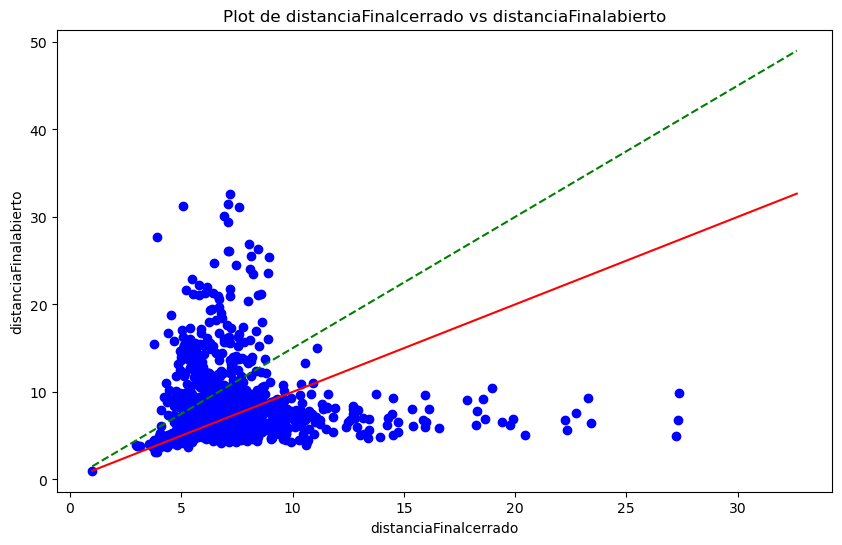

In [ ]:
# Crear el plot con los ejes invertidos
import numpy as np
import matplotlib.pyplot as plt


# Definir la función leer_columnas si no está definida en una celda anterior
def leer_columnas(input_path):
    col1, col2 = [], []
    with open(input_path, 'r') as infile:
        for line in infile:
            d1, d2 = line.strip().split('\t')
            col1.append(float(d1))
            col2.append(float(d2))
    return col1, col2

# Leer las columnas del archivo combinado
col1, col2 = leer_columnas(archivo_combinado)

# Añadir la línea y = x
x_vals = np.linspace(min(col1 + col2), max(col1 + col2), 100)

plt.figure(figsize=(10, 6))
plt.scatter(col2, col1, c='blue', marker='o')
plt.title('Plot de distanciaFinalcerrado vs distanciaFinalabierto')
plt.xlabel('distanciaFinalcerrado')
plt.ylabel('distanciaFinalabierto')
plt.plot(x_vals, 1.5 * x_vals, color='green', linestyle='--', label='y = 1.5x')
plt.plot(x_vals, x_vals, color='red', label='y = x')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
# Filtrar y guardar las distancias por encima del umbral y = 1.5x

def filtrar_distancias(col1, col2, umbral):
    distancias_filtradas = [(x, y) for x, y in zip(col1, col2) if y > umbral * x]
    return distancias_filtradas

# Leer el contenido del archivo combinado
def leer_columnas(input_path):
    col1, col2 = [], []
    with open(input_path, 'r') as infile:
        for line in infile:
            d1, d2 = line.strip().split('\t')
            col1.append(float(d1))
            col2.append(float(d2))
    return col1, col2

# Ruta del archivo combinado
archivo_combinado = 'distanciaFinal_combinado'

# Leer las columnas del archivo combinado
col1, col2 = leer_columnas(archivo_combinado)

# Filtrar las distancias por encima del umbral y = 1.5x
umbral = 1.5
distancias_filtradas = filtrar_distancias(col2, col1, umbral) #OJO SE INVIERTE ABIERTO Y CERRADO


# Ruta del archivo de salida
archivo_filtrado = 'distancias_filtradas1,5.txt'

# Guardar las distancias filtradas en un archivo
with open(archivo_filtrado, 'w') as outfile:
    for x, y in distancias_filtradas:
        outfile.write(f"{x}\t{y}\n")

print(f"Distancias por encima del umbral y = 1.5x guardadas en {archivo_filtrado}")

Distancias por encima del umbral y = 1.5x guardadas en distancias_filtradas1,5.txt


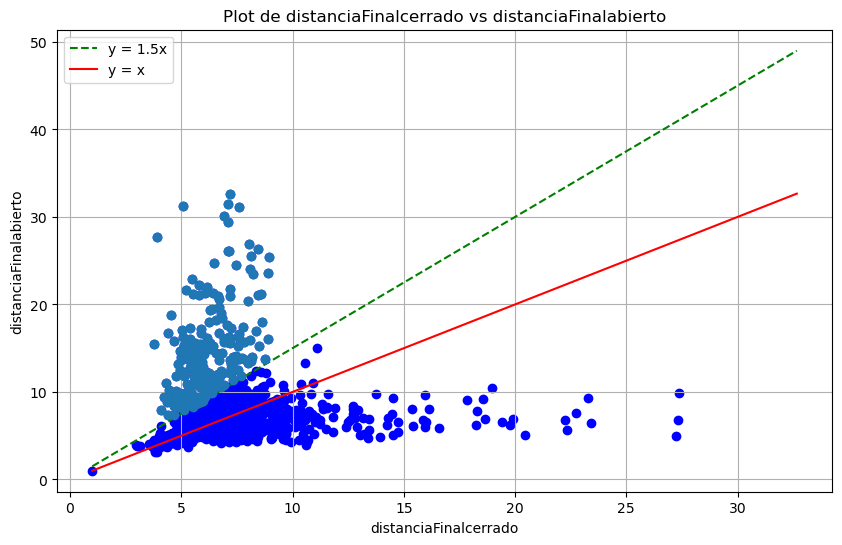

In [25]:
# ploteo distancias filtradas
# Crear el plot con los ejes invertidos
import numpy as np
import matplotlib.pyplot as plt

# Definir la función leer_columnas si no está definida en una celda anterior
def leer_columnas(input_path):
    col1, col2 = [], []
    with open(input_path, 'r') as infile:
        for line in infile:
            d1, d2 = line.strip().split('\t')
            col1.append(float(d1))
            col2.append(float(d2))
    return col1, col2

# Leer las columnas del archivo combinado
col1, col2 = leer_columnas(archivo_combinado)

# Añadir la línea y = x
x_vals = np.linspace(min(col1 + col2), max(col1 + col2), 100)

plt.figure(figsize=(10, 6))
plt.scatter(col2, col1, c='blue', marker='o')
plt.title('Plot de distanciaFinalcerrado vs distanciaFinalabierto')
plt.xlabel('distanciaFinalcerrado')
plt.ylabel('distanciaFinalabierto')
plt.plot(x_vals, 1.5 * x_vals, color='green', linestyle='--', label='y = 1.5x')
plt.plot(x_vals, x_vals, color='red', label='y = x')




with open('distancias_filtradas1,5.txt', 'r') as infile:
    col1=[]
    col2=[]
    for line in infile:
        d1, d2 = line.strip().split()
        col1.append(float(d1))
        col2.append(float(d2))

plt.plot(col1, col2, 'o')
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_68081/2551170756.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('res_contacts_filtrad03concat.dat', delim_whitespace=True,names=['#Res1', '#Res2', 'TotalFrac', 'Contacts'])
/tmp/ipykernel_68081/2551170756.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  distancias = pd.read_csv(distancias_file, delim_whitespace=True, names=[nombre_distancia])
/tmp/ipykernel_68081/2551170756.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  distancias = pd.read_csv(distancias_file, delim_whitespace=True, names=[nombre_distancia])


<function matplotlib.pyplot.show(close=None, block=None)>

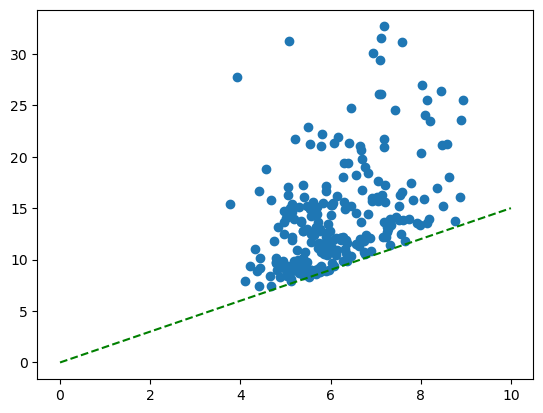

In [19]:
import pandas as pd
import numpy as np

# Agregar distancias a contactos calulados

def agregar_distancias_a_contactos(df, distancias_file, nombre_distancia):
    distancias = pd.read_csv(distancias_file, delim_whitespace=True, names=[nombre_distancia])
    df[nombre_distancia] = distancias
    return df

df = pd.read_csv('res_contacts_filtrad03concat.dat', delim_whitespace=True,names=['#Res1', '#Res2', 'TotalFrac', 'Contacts'])

df = agregar_distancias_a_contactos(df, 'distanciaFinalabierto_transformado', 'distanciaAbierto')

df = agregar_distancias_a_contactos(df, 'distanciaFinalcerrado_transformado', 'distanciaCerrado')

filtro = df['distanciaCerrado']* 1.5  <  df['distanciaAbierto']

df = df[filtro]

df[['#Res1' ,'#Res2' ,'TotalFrac', 'Contacts']].to_csv('res_contacts_filtrad03concat_Filtrado.dat', sep=' ', index=False)

import matplotlib.pyplot as plt

# Añadir la línea y = x
x_vals = np.linspace(0, 10, 100)

plt.plot(df['distanciaCerrado'], df['distanciaAbierto'], 'o')
plt.plot(x_vals, 1.5 * x_vals, color='green', linestyle='--', label='y = 1.5x')
plt.show

In [8]:
## hay que ver el formato de entrada

def agregar_formato_openmm(input_file, output_file):
    # Leer los datos desde el archivo de texto
    data = pd.read_csv(input_file, delim_whitespace=True, header=None)

    # Crear columnas de unos
    ones_column = np.ones((data.shape[0], 1), dtype=int)

    # Insertar las columnas de unos en las posiciones 0 y 2
    data.insert(0, 'Col0', ones_column)
    data.insert(2, 'Col2', ones_column)

    # Eliminar las ultimas dos columnas
    data.drop(data.columns[-2:], axis=1, inplace=True)
    

    # Guardar el resultado en un nuevo archivo
    data.to_csv(output_file, sep=' ', index=False, header=False)

In [24]:
agregar_formato_openmm('res_contacts_filtrad03concat_Filtrado.dat', 'res_contacts_filtrad03concat_Filtrado_openmm.dat')

agregar_formato_openmm('contactos_en_comun03.dat', 'contactos_en_comun03_openmm.dat')

/tmp/ipykernel_68081/2826760206.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(input_file, delim_whitespace=True, header=None)
/tmp/ipykernel_68081/2826760206.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(input_file, delim_whitespace=True, header=None)


In [34]:
concatenar_archivos('res_contacts_filtrad03concat_Filtrado_openmm.dat', 'contactos_en_comun03_openmm.dat', 'preContacts.contacts')

      1  #Res1  1.1  #Res2
0     1      1    1      2
1     1      1    1      3
2     1      2    1      3
3     1      2    1      4
4     1      3    1      4
...  ..    ...  ...    ...
5037  1    724    1    727
5038  1    630    1    727
5039  1    450    1    454
5040  1    603    1    606
5041  1   1133    1   1136

[5042 rows x 4 columns]
      1  #Res1  1.1  #Res2
0     1    929    1    932
1     1    274    1    277
2     1     65    1     71
3     1    360    1    930
4     1     69    1     72
...  ..    ...  ...    ...
5266  1    724    1    727
5267  1    630    1    727
5268  1    450    1    454
5269  1    603    1    606
5270  1   1133    1   1136

[5262 rows x 4 columns]


In [35]:

def filtrar_contactos_reciprocos(input_file, output_file,ncols):
    
    # Leer el archivo de entrada y filtrar los contactos repetidos
    contactos = {}
    with open(input_file, 'r') as infile:
        for line in infile:
            if ncols==4:
                parts = [line.strip().split()[1],line.strip().split()[3]]
            else:
                parts = [line.strip().split()[0],line.strip().split()[1]]
            if len(parts) == 2:
                contacto = tuple(sorted(parts))  # Ordenar para evitar duplicados como (2, 4) y (4, 2)
                if contacto in contactos:
                    contactos[contacto] += 1
                else:
                    contactos[contacto] = 1

In [36]:
filtrar_contactos_reciprocos('preContacts.contacts', 'contactos.contacts',4)

In [11]:
agregar_formato_openmm('contactos.contacts', 'contactos_abierto_openmm')

In [13]:
concatenar_archivos('contactos_en_comun03_openmm.dat','contactos_abierto_openmm', 'contactos_abierto_y_03')

      1      1.0  1.1   1.2
0     1  1.00000    1     2
1     1  1.00000    1     3
2     1  1.00000    1     4
3     1  1.00000    1     5
4     1  1.00000    1     6
...  ..      ...  ...   ...
4236  1  0.30472    1   276
4237  1  0.30424    1   674
4238  1  0.30392    1   603
4239  1  0.30178    1  1133
4240  1  0.30086    1    60

[4241 rows x 4 columns]
      1   #Res1  1.1   #Res2  1.0  1.2
0     1     1.0    1     2.0  NaN  NaN
1     1     1.0    1     3.0  NaN  NaN
2     1     2.0    1     3.0  NaN  NaN
3     1     2.0    1     4.0  NaN  NaN
4     1     3.0    1     4.0  NaN  NaN
...  ..     ...  ...     ...  ...  ...
5038  1   630.0    1   727.0  NaN  NaN
5039  1   450.0    1   454.0  NaN  NaN
5040  1   603.0    1   606.0  NaN  NaN
5041  1  1133.0    1  1136.0  NaN  NaN
5042  1     NaN    1     NaN  1.0  2.0

[5043 rows x 6 columns]
